# Task 1
Predictive Modeling


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

In [3]:
# 1. Load the dataset

data = pd.read_csv (r"C:\Users\arund\Downloads\Dataset  (1).csv")

data.head ()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
# 1. BASIC CLEANING


# Remove rows without ratings
data = data.dropna(subset=["Aggregate rating"])

# Convert Yes/No to binary
data["Has_Table_Booking_Flag"] = data["Has Table booking"].map({"Yes": 1, "No": 0})
data["Has_Online_Delivery_Flag"] = data["Has Online delivery"].map({"Yes": 1, "No": 0})

# Extract numerical features (example)
data["Name_Length"] = data["Restaurant Name"].str.len()


# Select features
features = [
    "Price range", 
    "Votes",
    "Has_Table_Booking_Flag",
    "Has_Online_Delivery_Flag",
    "Name_Length",
    "City"
]

X = data[features]
y = data["Aggregate rating"]


# 2. HANDLE CATEGORICAL FEATURES

categorical_features = ["City"]
numeric_features = [col for col in features if col not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)







In [8]:

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Build regression model pipeline (fixed: no '-------' separator)
model = Pipeline(
    steps=[
        ("preprocessing", preprocess),
        ("regressor", RandomForestRegressor(random_state=42))
    ]
)

In [9]:
# 4. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [10]:
# 5. TRAIN THE MODEL

model.fit(X_train, y_train)


# 6. PREDICTIONS

y_pred = model.predict(X_test)



In [11]:
# 7. MODEL EVALUATION

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Model Performance:
MAE  : 0.223
MSE  : 0.116
RMSE : 0.340
R²   : 0.949


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [13]:
# 3. Create Model List to Compare

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

# 4. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 5. Train & Evaluate each Model

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("regressor", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    }


# 6. Display Results

print("\nModel Comparison Results:\n")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"   MAE  : {metrics['MAE']:.3f}")
    print(f"   MSE  : {metrics['MSE']:.3f}")
    print(f"   RMSE : {metrics['RMSE']:.3f}")
    print(f"   R²   : {metrics['R²']:.3f}")
    print("-" * 40)


Model Comparison Results:

Linear Regression:
   MAE  : 1.016
   MSE  : 1.502
   RMSE : 1.226
   R²   : 0.340
----------------------------------------
Decision Tree:
   MAE  : 0.285
   MSE  : 0.197
   RMSE : 0.444
   R²   : 0.913
----------------------------------------
Random Forest:
   MAE  : 0.223
   MSE  : 0.116
   RMSE : 0.340
   R²   : 0.949
----------------------------------------


# Task 2
Customer Preference Analysis

In [15]:
# Keep only needed columns
data = data[["Cuisines", "Aggregate rating"]].dropna()

# If cuisines have multiple values (e.g., "North Indian, Chinese"),
# split them into separate rows
data_expanded = data.assign(Cuisines=data["Cuisines"].str.split(", "))
data_expanded = data_expanded.explode("Cuisines")

# Compute average rating for each cuisine
cuisine_rating = data_expanded.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending=False)

# Compute number of restaurants per cuisine
cuisine_count = data_expanded["Cuisines"].value_counts()

# Display results
print("\nAverage Rating by Cuisine:\n")
print(cuisine_rating)

print("\nNumber of Restaurants per Cuisine:\n")
print(cuisine_count)


Average Rating by Cuisine:

Cuisines
Sunda             4.900000
B�_rek            4.700000
Taiwanese         4.650000
Ramen             4.500000
Dim Sum           4.466667
                    ...   
Moroccan          1.620000
Awadhi            1.572727
Armenian          1.300000
Mineira           0.000000
Cuisine Varies    0.000000
Name: Aggregate rating, Length: 145, dtype: float64

Number of Restaurants per Cuisine:

Cuisines
North Indian      3960
Chinese           2735
Fast Food         1986
Mughlai            995
Italian            764
                  ... 
Fish and Chips       1
Malwani              1
Cuisine Varies       1
Soul Food            1
B�_rek               1
Name: count, Length: 145, dtype: int64


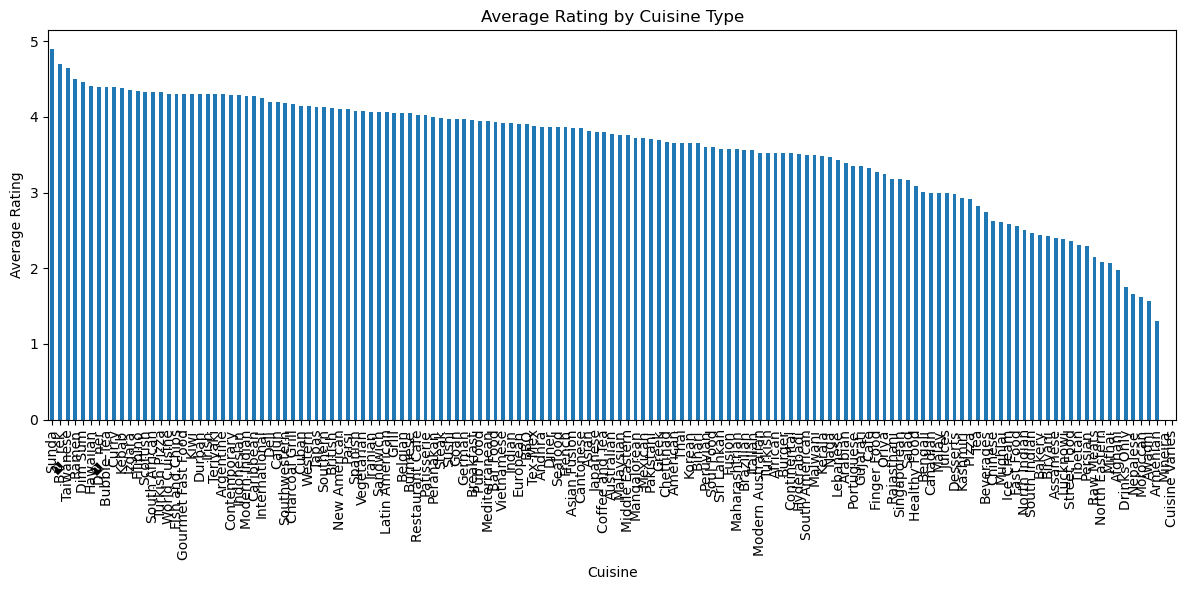

In [18]:
plt.figure(figsize=(12,6))
cuisine_rating.plot(kind="bar")
plt.title("Average Rating by Cuisine Type")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [20]:
# Keep only columns needed
data = data[["Cuisines", "Aggregate rating"]].dropna()

# Split multi-cuisine entries into separate rows
data_expanded = data.assign(Cuisines=data["Cuisines"].str.split(", "))
data_expanded = data_expanded.explode("Cuisines")

# Calculate average rating per cuisine
cuisine_avg_rating = (
    data_expanded.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Rating for Each Cuisine:")
print(cuisine_avg_rating)


Average Rating for Each Cuisine:
Cuisines
Sunda             4.900000
B�_rek            4.700000
Taiwanese         4.650000
Ramen             4.500000
Dim Sum           4.466667
                    ...   
Moroccan          1.620000
Awadhi            1.572727
Armenian          1.300000
Mineira           0.000000
Cuisine Varies    0.000000
Name: Aggregate rating, Length: 145, dtype: float64


# Task 3
Data Visualization

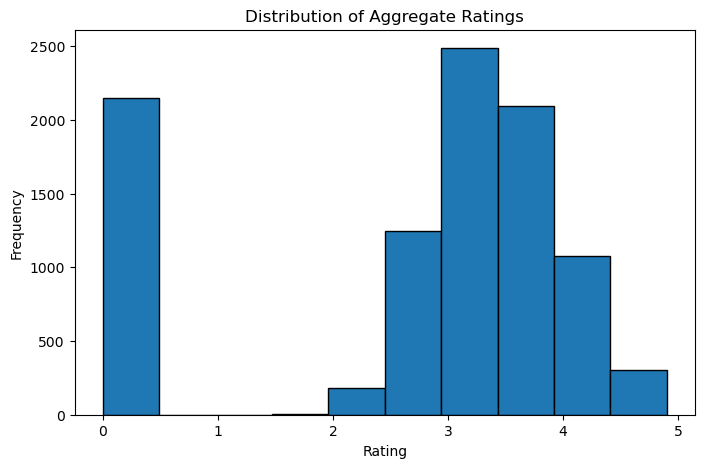

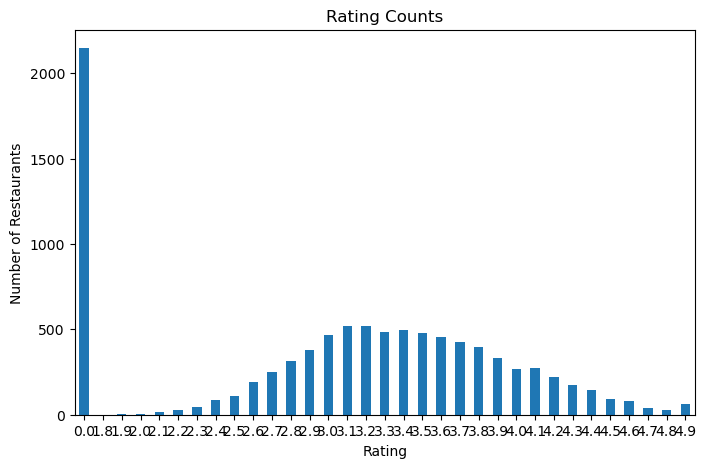

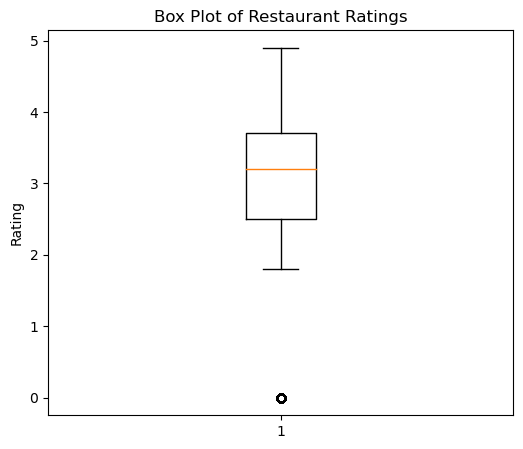

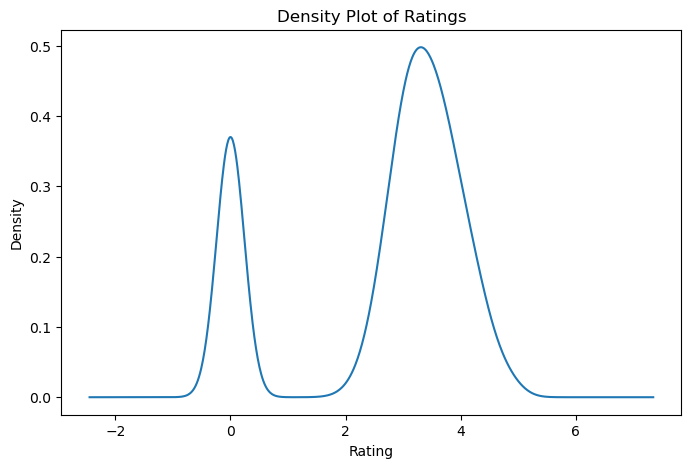

In [22]:

# Keep only valid ratings
ratings = data["Aggregate rating"].dropna()

# -------------------------------
# 1️⃣ Histogram of Ratings
# -------------------------------
plt.figure(figsize=(8,5))
plt.hist(ratings, bins=10, edgecolor='black')
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 2️⃣ Bar Plot (Rating Counts)
# -------------------------------
rating_counts = ratings.value_counts().sort_index()

plt.figure(figsize=(8,5))
rating_counts.plot(kind="bar")
plt.title("Rating Counts")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.show()

# -------------------------------
# 3️⃣ Box Plot of Ratings
# -------------------------------
plt.figure(figsize=(6,5))
plt.boxplot(ratings, vert=True)
plt.title("Box Plot of Restaurant Ratings")
plt.ylabel("Rating")
plt.show()

# -------------------------------
# 4️⃣ Density Plot (Optional)
# -------------------------------
plt.figure(figsize=(8,5))
ratings.plot(kind="density")
plt.title("Density Plot of Ratings")
plt.xlabel("Rating")
plt.show()


Available columns: ['Cuisines', 'Aggregate rating']

⚠ No column related to 'City' found! City-based graphs will be skipped.



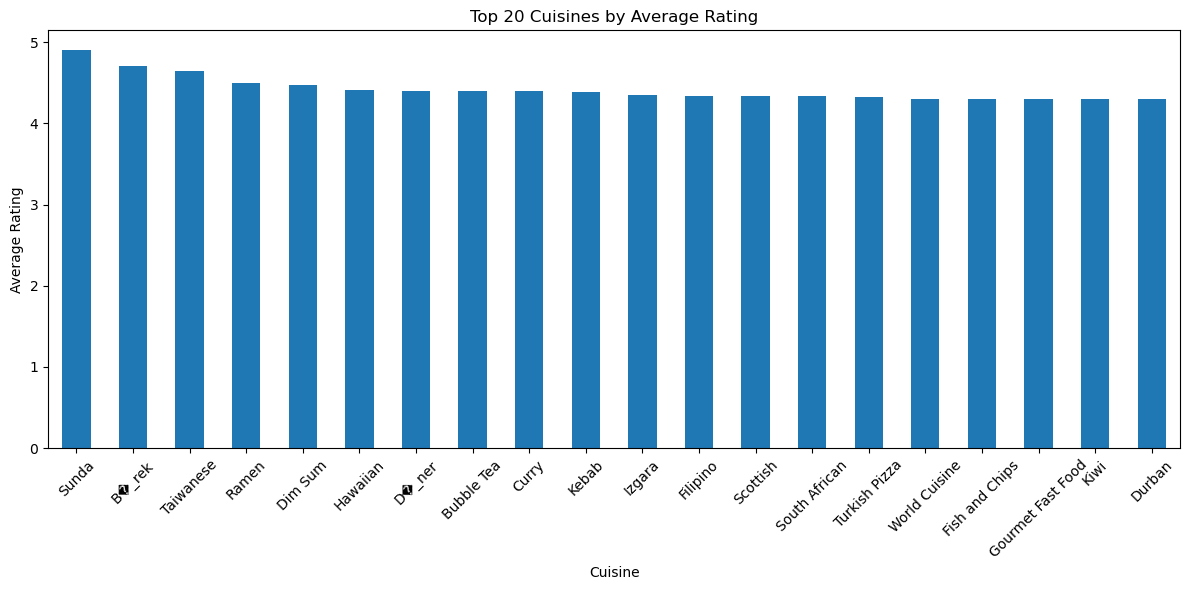


⚠ City-based plots skipped (City column missing).



In [24]:
# Print columns for debugging
print("Available columns:", data.columns.tolist())

# ---- Identify the City column dynamically ----
city_col = None
for col in data.columns:
    if "city" in col.lower():   # captures "City", "city name", etc.
        city_col = col
        break

if city_col:
    print(f"Detected city column: {city_col}")
else:
    print("\n⚠ No column related to 'City' found! City-based graphs will be skipped.\n")

# -------------------------------------------
# 1️⃣ Keep only needed columns (City only if it exists)
# -------------------------------------------
required_cols = ["Cuisines", "Aggregate rating"]
if city_col:
    required_cols.append(city_col)

data = data[required_cols].dropna()

# -------------------------------------------
# 2️⃣ Expand multi-cuisine rows
# -------------------------------------------
data_expanded = data.assign(Cuisines=data["Cuisines"].str.split(", "))
data_expanded = data_expanded.explode("Cuisines")

# -------------------------------------------
# 3️⃣ Average rating by cuisine
# -------------------------------------------
avg_cuisine_rating = (
    data_expanded.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

# Plot top 20 cuisines
plt.figure(figsize=(12,6))
avg_cuisine_rating.head(20).plot(kind='bar')
plt.title("Top 20 Cuisines by Average Rating")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------------------
# 4️⃣ Average rating by city (only if city exists)
# -------------------------------------------
if city_col:
    avg_city_rating = (
        data.groupby(city_col)["Aggregate rating"]
        .mean()
        .sort_values(ascending=False)
    )

    # City rating bar chart
    plt.figure(figsize=(12,6))
    avg_city_rating.plot(kind='bar')
    plt.title("Average Rating by City")
    plt.xlabel("City")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Top 10 cities
    plt.figure(figsize=(10,5))
    avg_city_rating.head(10).plot(kind="bar", color="orange")
    plt.title("Top 10 Cities With Highest Average Ratings")
    plt.xlabel("City")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("\n⚠ City-based plots skipped (City column missing).\n")


Detected City Column: None


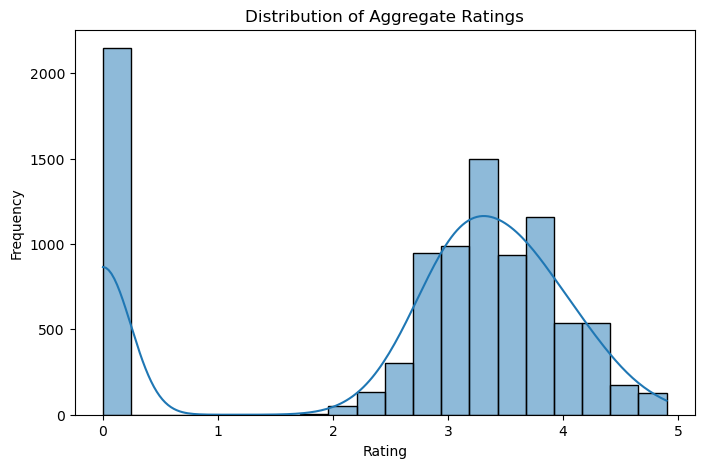

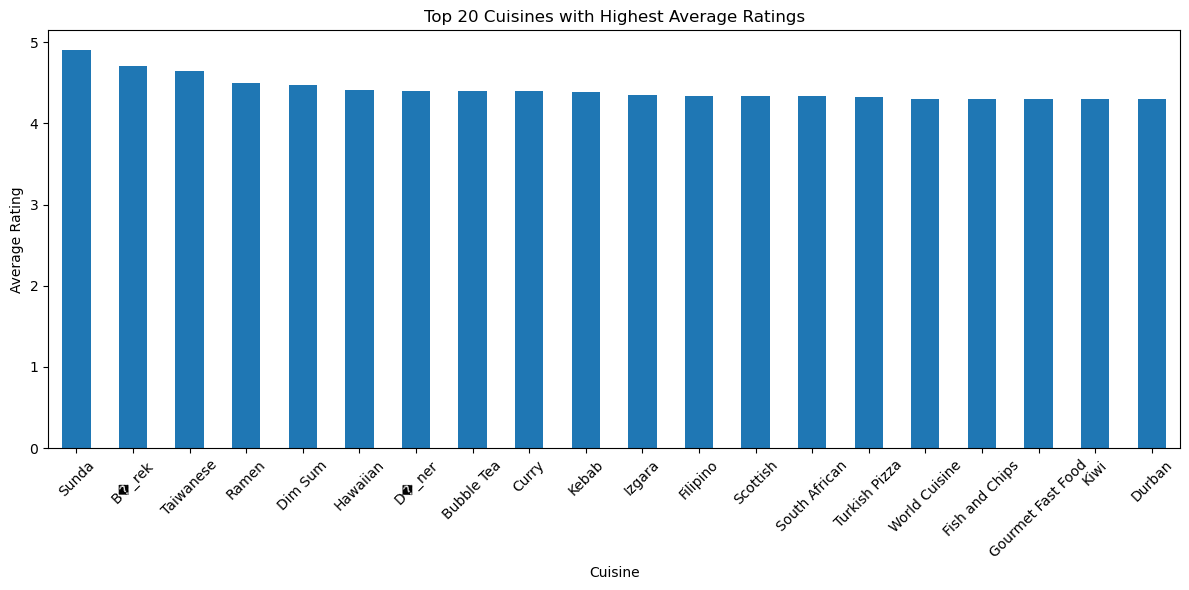

In [26]:
# Detect City column if present
city_col = None
for col in data.columns:
    if "city" in col.lower():
        city_col = col
        break

print("Detected City Column:", city_col)

# -------------------------------
# CLEAN BASIC DATA
# -------------------------------
data = data.dropna(subset=["Aggregate rating"])

# Convert Columns if present
if "Votes" in data.columns:
    data["Votes"] = pd.to_numeric(data["Votes"], errors="coerce").fillna(0)

if "Price range" in data.columns:
    data["Price range"] = pd.to_numeric(data["Price range"], errors="coerce")

# -------------------------------
# 1️⃣ Rating Distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(data["Aggregate rating"], kde=True, bins=20)
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 2️⃣ Rating vs Price Range
# -------------------------------
if "Price range" in data.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Price range", y="Aggregate rating", data=data)
    plt.title("Rating vs Price Range")
    plt.xlabel("Price Range")
    plt.ylabel("Rating")
    plt.show()

# -------------------------------
# 3️⃣ Rating vs Votes
# -------------------------------
if "Votes" in data.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x="Votes", y="Aggregate rating", data=data)
    plt.title("Rating vs Votes")
    plt.xlabel("Votes")
    plt.ylabel("Rating")
    plt.show()

# -------------------------------
# 4️⃣ Rating by Online Delivery
# -------------------------------
if "Has Online delivery" in data.columns or "Online delivery" in data.columns:
    online_col = "Has Online delivery" if "Has Online delivery" in data.columns else "Online delivery"

    plt.figure(figsize=(7,5))
    sns.boxplot(x=online_col, y="Aggregate rating", data=data)
    plt.title("Rating by Online Delivery Availability")
    plt.xlabel("Online Delivery")
    plt.ylabel("Rating")
    plt.show()

# -------------------------------
# 5️⃣ Rating by Table Booking
# -------------------------------
if "Has Table booking" in data.columns or "Table booking" in data.columns:
    table_col = "Has Table booking" if "Has Table booking" in data.columns else "Table booking"

    plt.figure(figsize=(7,5))
    sns.boxplot(x=table_col, y="Aggregate rating", data=data)
    plt.title("Rating by Table Booking Availability")
    plt.xlabel("Table Booking")
    plt.ylabel("Rating")
    plt.show()

# -------------------------------
# 6️⃣ Ratings by Cuisine (Top 20)
# -------------------------------
if "Cuisines" in data.columns:
    data_expanded = data.assign(Cuisines=data["Cuisines"].str.split(", "))
    data_expanded = data_expanded.explode("Cuisines")

    cuisine_rating = (data_expanded.groupby("Cuisines")["Aggregate rating"]
                      .mean()
                      .sort_values(ascending=False)
                     )

    plt.figure(figsize=(12,6))
    cuisine_rating.head(20).plot(kind="bar")
    plt.title("Top 20 Cuisines with Highest Average Ratings")
    plt.xlabel("Cuisine")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 7️⃣ Ratings by City (if available)
# -------------------------------
if city_col:
    avg_city_rating = data.groupby(city_col)["Aggregate rating"].mean()

    plt.figure(figsize=(12,6))
    avg_city_rating.plot(kind="bar")
    plt.title("Average Rating by City")
    plt.xlabel("City")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()